In [2]:
import kagglehub

kagglehub.dataset_download("yusufmurtaza01/grape-leaf-diseases", output_dir='data')

100%|██████████| 143M/143M [00:12<00:00, 12.4MB/s] 

Extracting files...


'data'

In [2]:
import numpy as np
import pandas as pd 
from tqdm import tqdm
import os 
from PIL import Image

image_path = 'data/grape/images/train/'
label_path = 'data/grape/labels/train/'

image_val_path = 'data/grape/images/val/'
label_val_path = 'data/grape/labels/val/'

raw_train_image = []
raw_val_image = []
records = []
for image_name in tqdm(os.listdir(image_path)):
    with Image.open(image_path + image_name) as img:
        raw_train_image.append(img.copy())     
    label_name = image_name.replace('.jpg', ".txt")
    with open(label_path + label_name, "r") as f:
        label = f.read()
    records.append({
        "file_name": image_name,
        "class": label[0],
    })

df_train = pd.DataFrame(records, columns=['file_name', 'class']) 

records = []
for image_name in tqdm(os.listdir(image_val_path)):
    with Image.open(image_val_path + image_name) as img:
        raw_val_image.append(img.copy()) 
    label_name = image_name.replace('.jpg', ".txt")
    with open(label_val_path + label_name, "r") as f:
        label = f.read()
    records.append({
        "file_name": image_name,
        "class": label[0],
    })

df_val = pd.DataFrame(records, columns=['file_name', 'class']) 

100%|██████████| 837/837 [00:00<00:00, 1394.04it/s]


# Step 1 - EDA

In [4]:
df_train

,file_name,class
0,pv_GRLB_image (276).jpg,3
1,pv_GRLB_image (331).jpg,3
2,pv_GRLB_image (324).jpg,3
3,pd_train_train_00553.jpg,2
4,pv_GRLB_image (84).jpg,3
...,...,...
3353,pv_GRBR_image (732).jpg,0
3354,pv_GRES_image (242).jpg,1
3355,pv_GRLB_image (1010).jpg,3
3356,pv_GRES_image (867).jpg,1


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3358 entries, 0 to 3357
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  3358 non-null   object
 1   class      3358 non-null   object
dtypes: object(2)
memory usage: 52.6+ KB


<Axes: title={'center': 'Class Distribution'}, ylabel='count'>

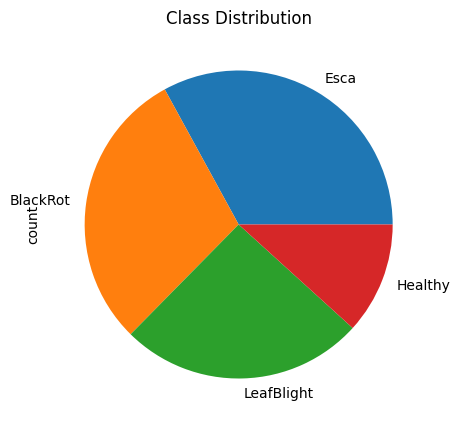

In [4]:
class_map = {'0': 'BlackRot', '1':'Esca', '2':'Healthy', '3':'LeafBlight'}
df_train['class'].replace(class_map).value_counts().plot.pie(figsize=(5, 5), title='Class Distribution')

### Samples of leaf images of every class

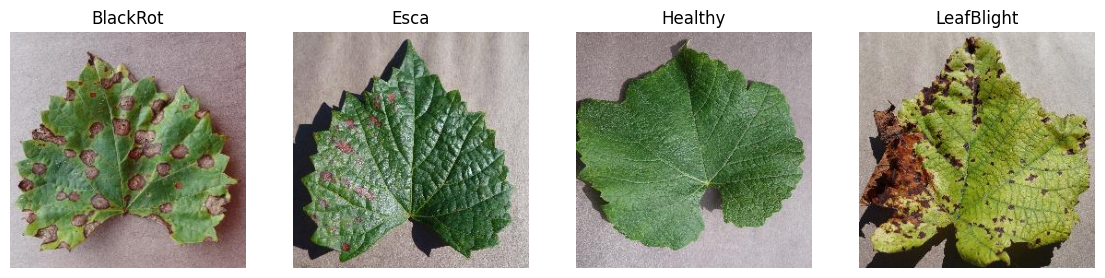

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

sample_each_class = df_train.groupby('class', group_keys=False).sample(n=1)
sample_each_class['class'] = sample_each_class['class'].replace(class_map)
f, axarr = plt.subplots(1, 4, figsize=(14,14))

for i in range(len(sample_each_class)): 
    image = Image.open(image_path + sample_each_class['file_name'].iloc[i])
    axarr[i].set_axis_off()
    axarr[i].set_title(sample_each_class["class"].iloc[i])
    axarr[i].imshow(image)

# Step 2 - Prepare MLFLow

Run `mlflow ui` in terminal

By default, it uses port 5000

On a web browser, type in `http://localhost:5000`

![homepage](asset/home_page.png)


In [7]:
import mlflow
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment("Predict leaf disease") 

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1777288140877, experiment_id='1', last_update_time=1777288140877, lifecycle_stage='active', name='Predict leaf disease', tags={}, trace_location=None, workspace='default'>

# Step 2 - Run DINOv2

In [12]:
from IPython.display import clear_output

os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "30"
from huggingface_hub import snapshot_download
model_id="facebook/dinov2-large"
snapshot_download(
    repo_id=model_id,     # model name on HF
    local_dir="dino", # your target directory
)
clear_output()

In [1]:
from transformers import AutoImageProcessor, AutoModel
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, ckpt="dino"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(ckpt)
        self.processor = AutoImageProcessor.from_pretrained(ckpt, use_fast=True)

    def forward(self, images):
        dev = next(self.parameters()).device
        inputs = self.processor(images=images, return_tensors="pt").to(dev)
        out = self.backbone(**inputs)
        feats = out.last_hidden_state[:, 0, :]
        return feats

model = Model().to('cuda:0').eval()

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


DINOv2 provides 1024 features. Let's see if ML models can classify leaf diseases.

# Step 3 - Prepare dataset

In [8]:
import torch
from torch.nn import functional as F
from pynvml import nvmlInit

nvmlInit()
mlflow.enable_system_metrics_logging()
with mlflow.start_run(run_name="DINOv2 embedding performance"):
    records = []
    with torch.no_grad():
        for i in tqdm(range(len(df_train)), desc=f'Creating training embeddings with DINO......'): 
            embedding = model([raw_train_image[i]]) 
            image_features = F.normalize(embedding, dim=1)[-1]
            vec = image_features.detach().cpu().numpy()
            record = {
                "file_name": df_train['file_name'].iloc[i],
                "class": df_train['class'].iloc[i],
            }
            record.update({f"emb_{i}": float(v) for i, v in enumerate(vec)})
            records.append(record)
    
    emb_cols = [f"emb_{i}" for i in range(len(vec))]
    columns = ['file_name', 'class'] + emb_cols
    df_train = pd.DataFrame(records, columns=columns)
    
    records = []
    with torch.no_grad():
        for i in tqdm(range(len(df_val)), desc=f'Creating validation embeddings with DINO......'): 
            embedding = model([raw_val_image[i]]) 
            image_features = F.normalize(embedding, dim=1)[-1]
            vec = image_features.detach().cpu().numpy()
            record = {
                "file_name": df_val['file_name'].iloc[i],
                "class": df_val['class'].iloc[i],
            }
            record.update({f"emb_{i}": float(v) for i, v in enumerate(vec)})
            records.append(record)
    
    emb_cols = [f"emb_{i}" for i in range(len(vec))]
    columns = ['file_name', 'class'] + emb_cols
    df_val = pd.DataFrame(records, columns=columns)

2026/04/27 12:17:43 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
Creating validation embeddings with DINO......: 100%|██████████| 837/837 [01:18<00:00, 10.69it/s]
2026/04/27 12:24:18 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/27 12:24:18 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run DINOv2 embedding performance at: http://localhost:5000/#/experiments/1/runs/b8f3f848cffd433bad43a7da2e45e8e4
🧪 View experiment at: http://localhost:5000/#/experiments/1


Back to MLFlow Server, we can see how resources are utilised to perform the embeddings.

![system_metric](asset/system_metrics.png)

In [9]:
df_train.head()

,file_name,class,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,...,emb_1014,emb_1015,emb_1016,emb_1017,emb_1018,emb_1019,emb_1020,emb_1021,emb_1022,emb_1023
0,pv_GRLB_image (276).jpg,3,0.005609,0.026691,-0.013530,-0.024079,-0.047690,0.032188,0.014523,-0.021603,...,0.022234,-0.029884,0.025402,0.042190,0.048998,-0.002104,0.033958,-0.043511,0.023339,-0.025685
1,pv_GRLB_image (331).jpg,3,-0.008796,0.028584,-0.027225,0.007354,-0.007984,0.013127,0.010768,-0.009566,...,0.031564,-0.028286,0.010041,0.041750,0.061825,-0.012096,0.024720,-0.054119,0.011213,-0.006484
2,pv_GRLB_image (324).jpg,3,-0.021868,0.014029,-0.006329,0.006911,-0.023102,0.025936,-0.008625,-0.002450,...,0.009060,-0.014223,0.021226,0.029130,0.038088,-0.011037,0.034926,-0.029237,0.003529,-0.022845
3,pd_train_train_00553.jpg,2,-0.063117,0.021732,-0.007140,-0.044538,0.002249,0.005186,-0.022022,-0.001782,...,0.061000,-0.054089,0.022265,-0.004405,0.002460,0.023007,-0.016084,-0.023656,0.034615,-0.015629
4,pv_GRLB_image (84).jpg,3,-0.014943,0.051540,-0.009317,0.000896,-0.020659,0.023857,-0.005506,-0.002440,...,0.020371,-0.020880,0.007513,0.045108,0.061788,-0.013339,0.041025,-0.041374,0.012063,-0.023576


In [12]:
from sklearn.model_selection import  StratifiedKFold, cross_val_score

df_ml_input = df_train.drop(columns=["file_name", 'class'])
df_ml_output = df_train["class"].astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 4 - Hyperparameter tuning & Train ML
We will train KNN and XGBoost to compare classification performance.

In [15]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import clear_output

def objective(trial):
    params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 50),
            "weights":     trial.suggest_categorical("weights", ["uniform", "distance"]),
            "algorithm":   trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
            "leaf_size":   trial.suggest_int("leaf_size", 10, 60),
            "p":           trial.suggest_int("p", 1, 2),  # 1 = Manhattan, 2 = Euclidean
            "metric":      trial.suggest_categorical("metric", ["minkowski", "euclidean", "manhattan"]),
            }
    
    model = KNeighborsClassifier(**params)
    with mlflow.start_run(nested=True):
        scores = cross_val_score(
            model, df_ml_input, df_ml_output,
            cv=cv,
            scoring='roc_auc_ovr',
            n_jobs=-1
        )    
        mlflow.log_params(params)
        mlflow.log_metric("roc_auc_ovr", scores.mean())
        mlflow.log_param("trial_number", trial.number)
        return scores.mean()  

with mlflow.start_run(run_name="KNN hyperparameter finetuning"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    clear_output()

2026/04/27 12:55:34 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/27 12:55:34 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run KNN hyperparameter finetuning at: http://localhost:5000/#/experiments/1/runs/dc6abbbf39ec45dd8cde8dbe1dfabc94
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [16]:
knn = KNeighborsClassifier(**study.best_params)
knn.fit(df_ml_input, df_ml_output)

KNeighborsClassifier(algorithm='ball_tree', leaf_size=46, metric='manhattan',
                     n_neighbors=7, p=1, weights='distance')

In [18]:
from xgboost import XGBClassifier

def objective(trial):
    params = {
        'n_estimators'       : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'          : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'   : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'gamma'              : trial.suggest_float('gamma', 0.0, 1.0),
        'eval_metric'        : 'auc',
        'enable_categorical' : True,
        'verbosity'          : 0
    }

    model = XGBClassifier(**params,device="cuda")
    with mlflow.start_run(nested=True):
        scores = cross_val_score(
            model, df_ml_input, df_ml_output,
            cv=cv,
            scoring='roc_auc_ovr',
            n_jobs=-1
        )    
        mlflow.log_params(params)
        mlflow.log_metric("roc_auc_ovr", scores.mean())
        mlflow.log_param("trial_number", trial.number)
        return scores.mean()  

with mlflow.start_run(run_name="XGBoost hyperparameter finetuning"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10, show_progress_bar=True)
clear_output()

In [19]:
xg = XGBClassifier(**study.best_params, device="cuda")
xg.fit(df_ml_input, df_ml_output)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7976065228477784, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.5570757240250982, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.18868551110649232,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=550, n_jobs=None,
              num_parallel_tree=None, ...)

# Step 5 - Evaluation

## KNN evaluation

In [20]:
X_test = df_val.drop(columns=["file_name", 'class'])
y_test = df_val["class"].astype(int)

In [21]:
class_map = {0: 'BlackRot', 1:'Esca', 2:'Healthy', 3:'LeafBlight'}

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, accuracy_score, auc
)

# Full probability matrix: (n_samples, n_classes)
val_proba = knn.predict_proba(X_test)

# Predicted class labels
val_preds = np.argmax(val_proba, axis=1)

print("=" * 50)
print("📊 FULL MULTICLASS EVALUATION REPORT")
print("=" * 50)

# ROC-AUC (One-vs-Rest)
print(
    f"ROC-AUC Score  : "
    f"{roc_auc_score(y_test, val_proba, multi_class='ovr', average='weighted'):.5f}"
)

print(f"Accuracy       : {accuracy_score(y_test, val_preds):.5f}")
print(f"F1 Score       : {f1_score(y_test, val_preds, average='weighted'):.5f}")

print("\n📋 Classification Report:")
print(classification_report(pd.Series(y_test).replace(class_map), pd.Series(val_preds).replace(class_map)))

📊 FULL MULTICLASS EVALUATION REPORT
ROC-AUC Score  : 0.99995
Accuracy       : 0.98805
F1 Score       : 0.98802

📋 Classification Report:
              precision    recall  f1-score   support

    BlackRot       1.00      0.96      0.98       248
        Esca       0.97      1.00      0.99       276
     Healthy       0.99      0.99      0.99        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.99       837
   macro avg       0.99      0.99      0.99       837
weighted avg       0.99      0.99      0.99       837



/tmp/ipykernel_45573/1858681560.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dev/anaconda3/envs/genai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


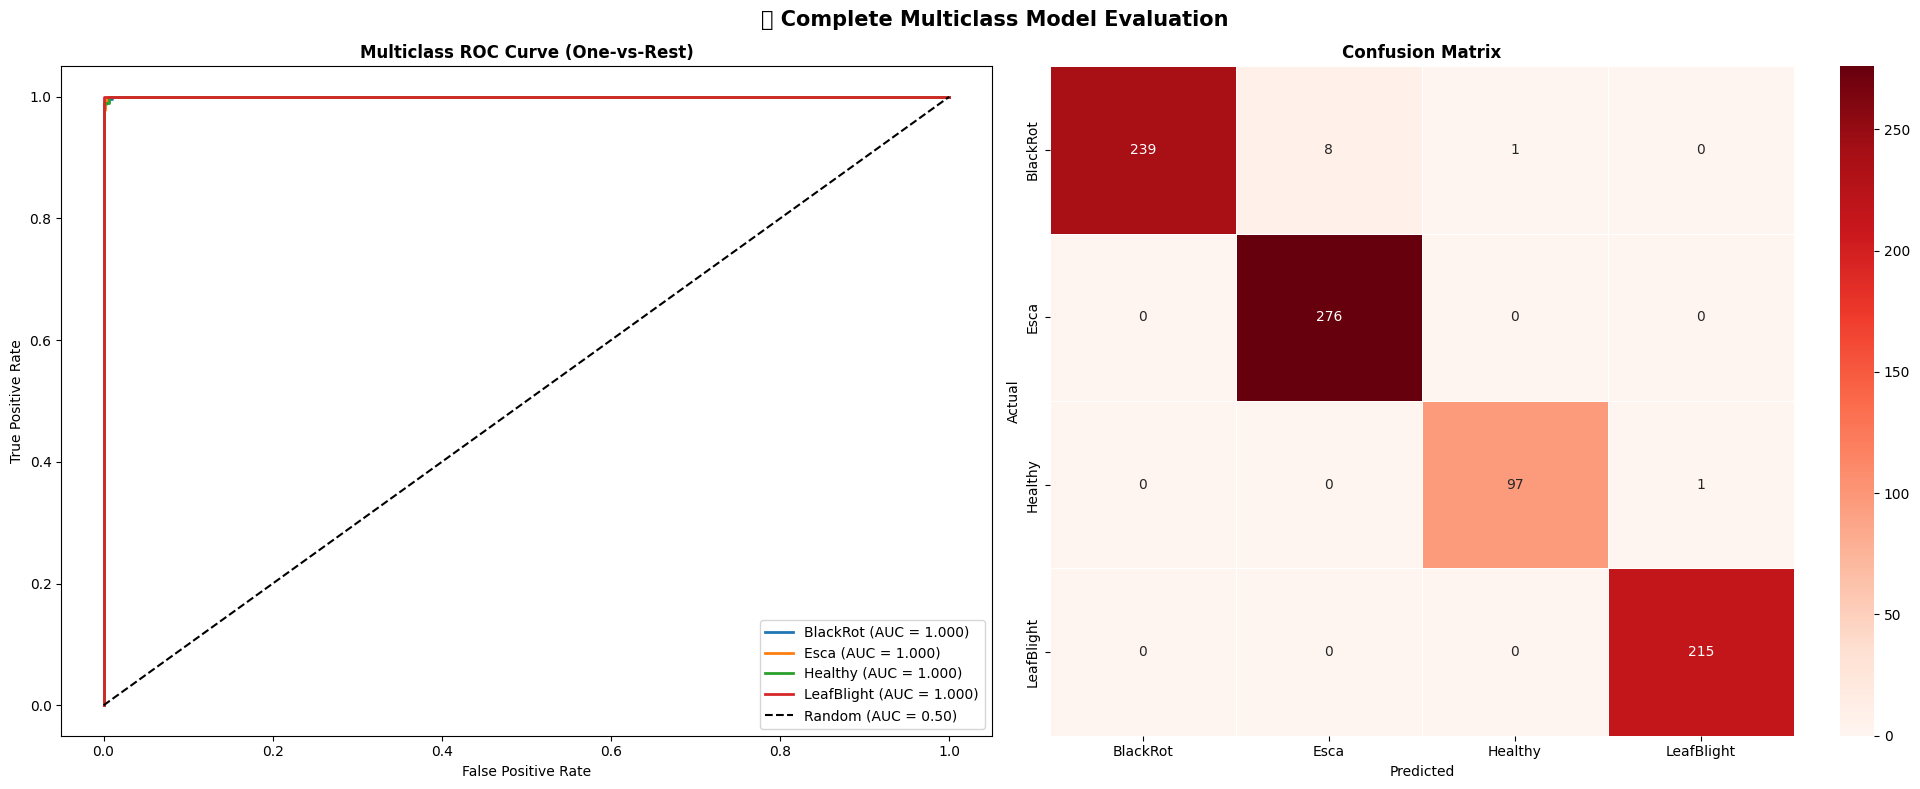

In [22]:
from sklearn.preprocessing import label_binarize
import seaborn as sns
 
class_names = knn.classes_
n_classes = len(class_names)

y_test_bin = label_binarize(y_test, classes=class_names)
class_names = pd.Series(xg.classes_).replace(class_map)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# =============================
# Plot 1: Multiclass ROC (OvR)
# =============================
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr, tpr, lw=2,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

# Random baseline
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.50)")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Multiclass ROC Curve (One-vs-Rest)", fontweight="bold")
axes[0].legend(loc="lower right")

# =============================
# Plot 2: Confusion Matrix
# =============================
cm = confusion_matrix(y_test, val_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# =============================
# Final layout
# =============================
plt.suptitle("📊 Complete Multiclass Model Evaluation",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## XGBoost evaluation

In [23]:
val_proba = xg.predict_proba(X_test)

# Predicted class labels
val_preds = np.argmax(val_proba, axis=1)

print("=" * 50)
print("📊 FULL MULTICLASS EVALUATION REPORT")
print("=" * 50)

# ROC-AUC (One-vs-Rest)
print(
    f"ROC-AUC Score  : "
    f"{roc_auc_score(y_test, val_proba, multi_class='ovr', average='weighted'):.5f}"
)

print(f"Accuracy       : {accuracy_score(y_test, val_preds):.5f}")
print(f"F1 Score       : {f1_score(y_test, val_preds, average='weighted'):.5f}")

print("\n📋 Classification Report:")
print(classification_report(pd.Series(y_test).replace(class_map), pd.Series(val_preds).replace(class_map)))

📊 FULL MULTICLASS EVALUATION REPORT
ROC-AUC Score  : 0.99993
Accuracy       : 0.99283
F1 Score       : 0.99283

📋 Classification Report:
              precision    recall  f1-score   support

    BlackRot       0.99      0.98      0.99       248
        Esca       0.99      0.99      0.99       276
     Healthy       0.99      1.00      0.99        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.99       837
   macro avg       0.99      0.99      0.99       837
weighted avg       0.99      0.99      0.99       837



/home/dev/anaconda3/envs/genai/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [13:08:59] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


/tmp/ipykernel_45573/3628158118.py:62: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dev/anaconda3/envs/genai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


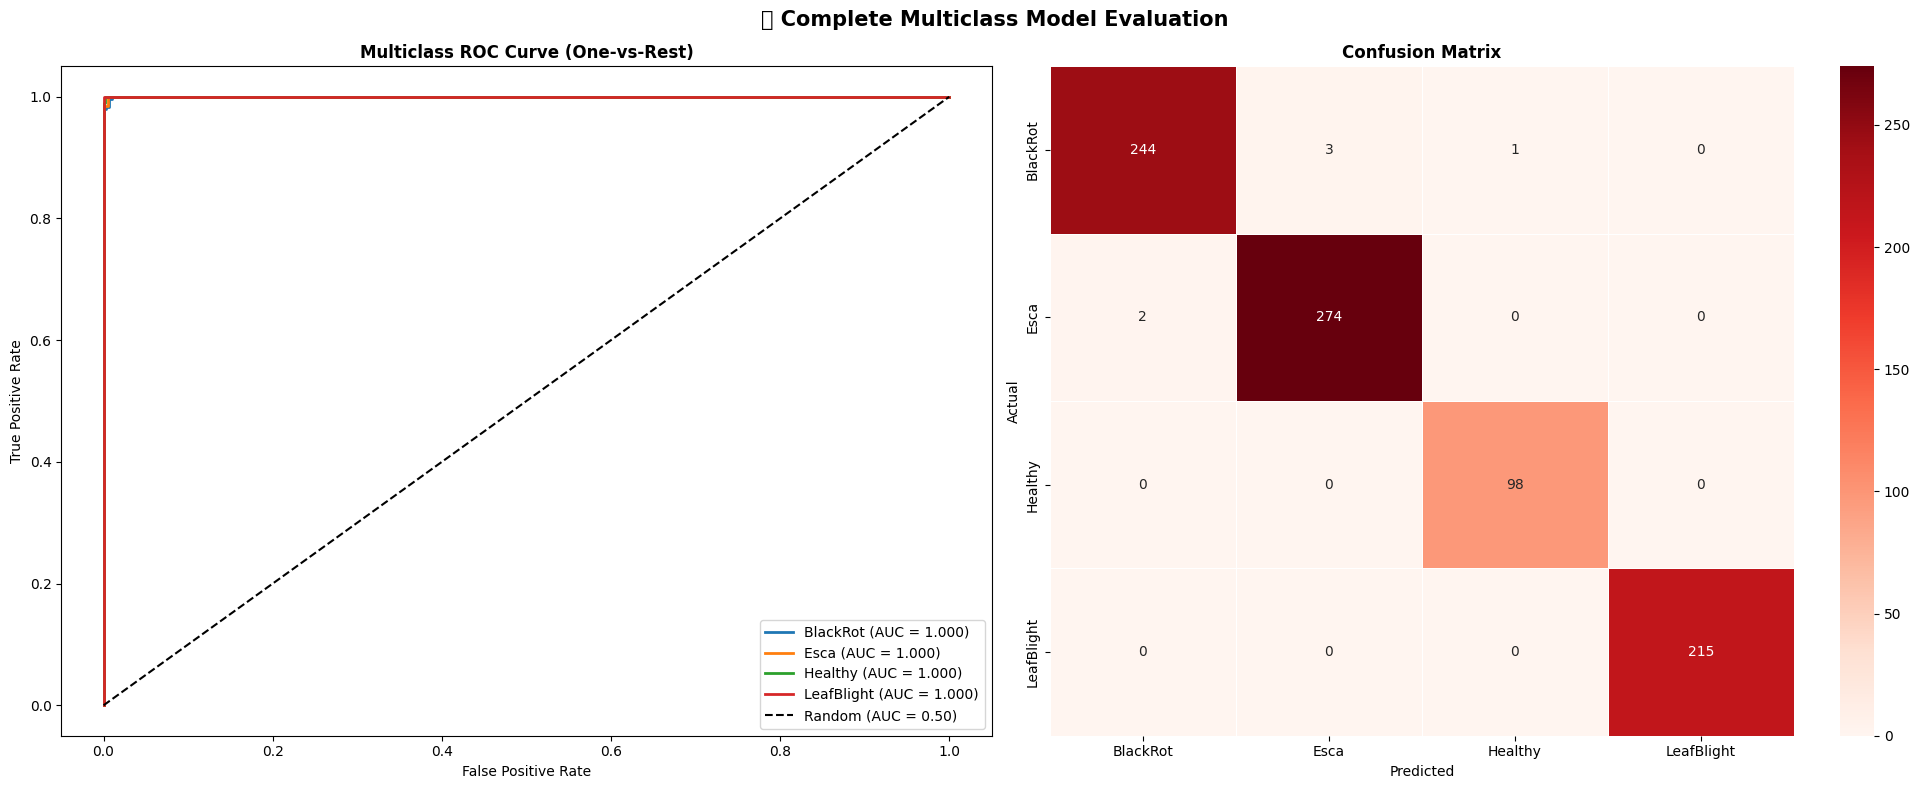

In [24]:
from sklearn.preprocessing import label_binarize

# -----------------------------
# Setup
# -----------------------------
class_names = xg.classes_
n_classes = len(class_names)

val_proba = xg.predict_proba(X_test)
val_preds = np.argmax(val_proba, axis=1)

y_test_bin = label_binarize(y_test, classes=class_names)
class_names = pd.Series(xg.classes_).replace(class_map)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# =============================
# Plot 1: Multiclass ROC (OvR)
# =============================
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr, tpr, lw=2,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

# Random baseline
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.50)")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Multiclass ROC Curve (One-vs-Rest)", fontweight="bold")
axes[0].legend(loc="lower right")

# =============================
# Plot 2: Confusion Matrix
# =============================
cm = confusion_matrix(y_test, val_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# =============================
# Final layout
# =============================
plt.suptitle("📊 Complete Multiclass Model Evaluation",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Step 6 - Deploy model

In [ ]:
mlflow.pytorch.log_model(model, name="DINOv2")
mlflow.xgboost.log_model(xg, name="XGBoost")
mlflow.sklearn.log_model(knn, name="KNN")

DINOv2 should appear in MLFLow

![log models](asset/logging_model.png)

Register each model

![register](asset/register_model.png)

![confirm](asset/confirm_register.png)

# Step 7 - Serve model

Go to terminal and type the following:

`export MLFLOW_TRACKING_URI=http://localhost:5000`

Install pyenv:

https://github.com/pyenv/pyenv#installation

`mlflow models serve -m models:/leaf_dino/1 -p 5001` DINO

`mlflow models serve -m models:/leaf_xg/1 -p 5002` XGBoost

`mlflow models serve -m models:/leaf_knn/1 -p 5003` KNN

Restart the kernel and use the `step 2` notebook to use the endpoints.